In [1]:
import itertools

import numpy as np
import seaborn as sns
from matplotlib import collections, colormaps, legend_handler, patches
from matplotlib import pyplot as plt
from scipy import linalg, optimize, stats

from nustattools import plotting as nuplt

In [2]:
rng = np.random.default_rng()

In [3]:
# Create the correlated covariance matrix
N = 3
cov = np.eye(N) * 0.2**2

u = np.array([2,-1,-2])
u = u[:, np.newaxis]
cov += u @ u.T

u = np.array([1,1,1]) * 0.5
u = u[:, np.newaxis]
cov += u @ u.T

In [4]:
err = np.sqrt(np.diag(cov))
cor = cov / err[:, np.newaxis] / err[np.newaxis, :]
covinv = np.linalg.inv(cov)
np.linalg.svd(cov, compute_uv=False), np.linalg.svd(cor, compute_uv=False)

(array([9.07019253, 0.75980747, 0.04      ]),
 array([2.71923588, 0.26462824, 0.01613588]))

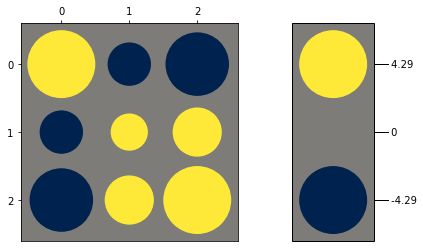

In [5]:
nuplt.hinton(cov, legend=True)
plt.savefig("plots/simple-cov.pdf")

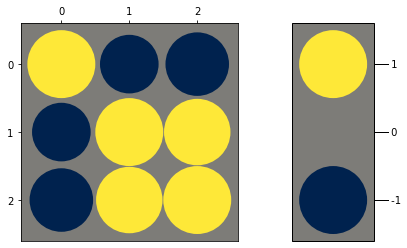

In [6]:
nuplt.hinton(cor, legend=True)
plt.savefig("plots/simple-cor.pdf")

In [7]:
# Generate some random data
x = np.arange(0, N)
y = rng.multivariate_normal([0] * N, cov)
y

array([ 0.69918299, -0.7805608 , -1.05604068])

In [8]:
# Define correct and wrong M-distances
def correct_dist(ymodel):
    dy = (ymodel - y)[:,np.newaxis]
    return (dy.T @ covinv @ dy).flat

def wrong_dist(ymodel):
    dy = (ymodel - y)
    return np.sum(dy**2 / err**2)

In [9]:
# Scale data to have target p-value
p = 0.32
chi2 = stats.chi2(df=N)
M = np.sqrt(correct_dist(np.array([0]*N)))
Mc = np.sqrt(chi2.isf(p))
y *= Mc/M

In [10]:
# Re-define correct and wrong M-distances
def correct_dist(ymodel):
    dy = (ymodel - y)[:,np.newaxis]
    return (dy.T @ covinv @ dy).flat

def wrong_dist(ymodel):
    dy = (ymodel - y)
    return np.sum(dy**2 / err**2)

In [39]:
# Do a correct fit
Nc = 1
def correct_fun(a):
    return np.sum([a[i]*x**i for i in range(Nc)], axis=0)

def correct_opt(a):
    return correct_dist(correct_fun(a))

correct_ret = optimize.minimize(correct_opt, x0=[0]*Nc)
chi_correct = correct_ret.fun
y_correct = correct_fun(correct_ret.x)

In [40]:
# Do a wrong fit
Nw = 2
def wrong_fun(a):
    return np.sum([a[i]*x**i for i in range(Nw)], axis=0)

def wrong_opt(a):
    return wrong_dist(wrong_fun(a))

wrong_ret = optimize.minimize(wrong_opt, x0=[0]*Nw)
chi_wrong=correct_dist(wrong_fun(wrong_ret.x))[0]
y_wrong = wrong_fun(wrong_ret.x)

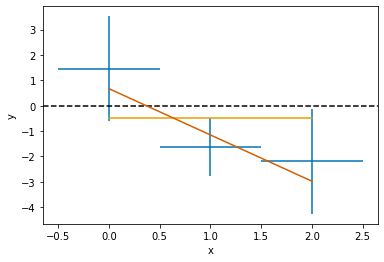

In [41]:
plt.errorbar(x, y, yerr=np.sqrt(np.diag(cov)), xerr=0.5, fmt=" ")
plt.axhline(0, color="k", linestyle="--")
plt.plot(x, correct_fun(correct_ret.x))
plt.plot(x, wrong_fun(wrong_ret.x))
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("plots/simple-diag.pdf")
chi_truth = correct_dist(correct_fun([0]*Nc))[0]

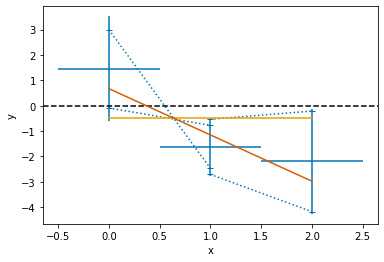

In [42]:
bars = nuplt.corlines(x, y, cov, xerr=0.5, corlinestyle=":")
plt.axhline(0, color="k", linestyle="--")
plt.plot(x, correct_fun(correct_ret.x))
plt.plot(x, wrong_fun(wrong_ret.x))
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("plots/simple-corlines.pdf")

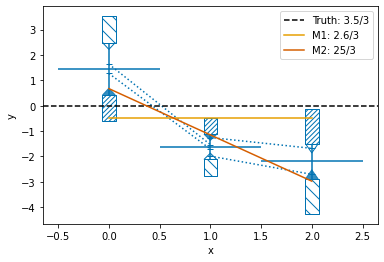

In [43]:
ret = {}
nuplt.pcplot(x, y, cov, return_dict=ret, scaling="second", xerr=0.5)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truth:.2g}/{N}")
plt.plot(x, correct_fun(correct_ret.x), label=f"M1: {chi_correct:.2g}/{N}")
plt.plot(x, wrong_fun(wrong_ret.x), label=f"M2: {chi_wrong:.2g}/{N}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/simple-pcplot.pdf")

In [44]:
ret

{'K': array([[ 1.05081414,  0.09064445, -0.23571635],
        [ 0.09064445,  0.24406681,  0.25303318],
        [-0.23571635,  0.25303318,  0.47725504]]),
 'u': array([-1.79977384,  1.02270875,  1.95262515]),
 'w': array([ 0.28144372, -0.55095118,  0.78564765]),
 'yconderr': array([0.76454513, 0.25197945, 0.33396498])}

-2.071231517720798 2.071231517720798


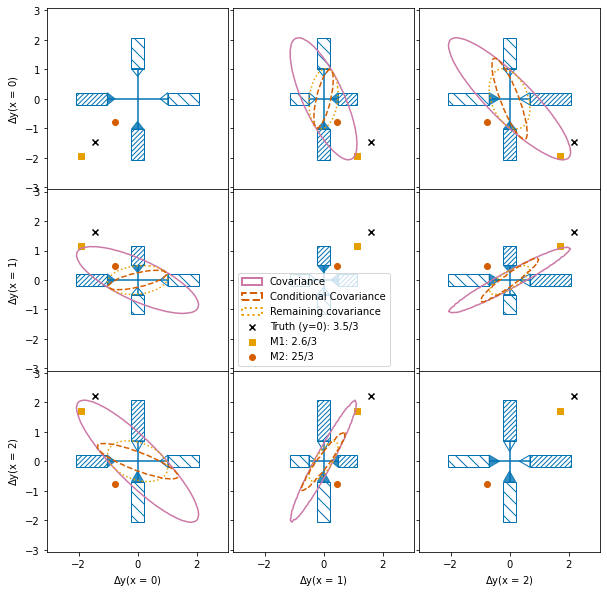

In [50]:
fig, axs = plt.subplots(
    N,
    N,
    sharex="col",
    sharey="row",
    figsize=(10, 10),
    gridspec_kw=dict(wspace=0, hspace=0),
)
ymin = np.min(-err)
ymax = np.max(+err)
print(ymin, ymax)
xx, yy = list(zip(*itertools.product(np.linspace(ymin - 1, ymax + 1, 50), repeat=2)))
xx = np.array(xx)
yy = np.array(yy)

for ix, iy in itertools.product(range(N), repeat=2):
    # axs[iy][ix].set_adjustable("box")
    axs[iy][ix].set_aspect("equal", "box")

    if ix == 0:
        axs[iy, ix].set_ylabel(f"$\Delta$y(x = {x[iy]:.4g})")
    if iy == len(x) - 1:
        axs[iy, ix].set_xlabel(f"$\Delta$y(x = {x[ix]:.4g})")

    xycov = cov[(ix, iy), :][:, (ix, iy)]
    xyK = ret["K"][(ix, iy), :][:, (ix, iy)]
    xycondinv = np.linalg.inv(cov)[(ix, iy), :][:, (ix, iy)]

    if ix == iy:
        xycov[0, 1] = xycov[1, 0] = 0
        xyK[0, 1] = xyK[1, 0] = 0
        xycondinv[0, 1] = xycondinv[1, 0] = 0

    xerr = np.sqrt(xycov[0, 0])
    yerr = np.sqrt(xycov[-1, -1])
    xKerr = np.sqrt(xyK[0, 0])
    yKerr = np.sqrt(xyK[-1, -1])
    xyu = ret["u"][
        (ix, iy),
    ]
    xyw = ret["w"][
        (ix, iy),
    ]
    xconderr = ret["yconderr"][ix]
    yconderr = ret["yconderr"][iy]
    axs[iy][ix].errorbar(0, 0, xerr=xKerr, yerr=yKerr, color="C0")

    # Covariance ellipse
    xycovinv = np.linalg.inv(xycov)
    dx = xx - 0
    dy = yy - 0
    dd = np.array((dx, dy)).T
    zz = (dd[..., np.newaxis, :] @ xycovinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        ell = axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C3")

    # Remaining covariance ellipse
    xyKinv = np.linalg.inv(xyK)
    zz = (dd[..., np.newaxis, :] @ xyKinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        pass
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C1", linestyles=":")

    # Conditional covariance ellipse
    zz = (dd[..., np.newaxis, :] @ xycondinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if ix != iy:
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C2", linestyles="--")

    # 1st component boxes
    xw = yw = ymax / 5
    patch = patches.Rectangle(
        (0 - xerr, 0 - yw / 2),
        xerr - xKerr,
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] < 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (0 + xerr, 0 - yw / 2),
        -(xerr - xKerr),
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] >= 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (0 - xw / 2, 0 - yerr),
        xw,
        yerr - yKerr,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[1] < 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (0 - xw / 2, 0 + yerr),
        xw,
        -(yerr - yKerr),
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[1] >= 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)

    # Last component triangles
    patch = patches.Polygon(
        [
            (0 - xKerr, 0 - yw / 2),
            (0 - xconderr, 0),
            (0 - xKerr, 0 + yw / 2),
        ],
        edgecolor="C0",
    )
    if xyw[0] < 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (0 + xKerr, 0 - yw / 2),
            (0 + xconderr, 0),
            (0 + xKerr, 0 + yw / 2),
        ],
        edgecolor="C0",
    )
    if xyw[0] >= 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (0 - xw / 2, 0 - yKerr),
            (0, 0 - yconderr),
            (0 + xw / 2, 0 - yKerr),
        ],
        edgecolor="C0",
    )
    if xyw[1] < 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (0 - xw / 2, 0 + yKerr),
            (0, 0 + yconderr),
            (0 + xw / 2, 0 + yKerr),
        ],
        edgecolor="C0",
    )
    if xyw[1] >= 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)

    # Truth
    tru = axs[iy][ix].scatter(-y[ix], -y[iy], marker="x", color="k")
    wro = axs[iy][ix].scatter(y_wrong[ix]-y[ix], y_wrong[iy]-y[iy], marker="o", color="C2")
    cor = axs[iy][ix].scatter(y_correct[ix]-y[ix], y_correct[iy]-y[iy], marker="s", color="C1")

leg_artists = [
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C3", linestyle="-", facecolor="none"),
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C2", linestyle="--", facecolor="none"),
    patches.Ellipse((0, 0), 1, 1, linewidth=2, edgecolor="C1", linestyle=":", facecolor="none"),
    tru,
    cor,
    wro,
]
leg_labels = [
    "Covariance",
    "Conditional Covariance",
    "Remaining covariance",
    f"Truth (y=0): {chi_truth:.2g}/{N}",
    f"M1: {chi_correct:.2g}/{N}",
    f"M2: {chi_wrong:.2g}/{N}",
]
axs[1][1].legend(leg_artists, leg_labels)
plt.savefig("plots/simple-full.pdf")